# CTGAN notebook demo

We split the sample transactions into 60% training, 20% validation, and 20% test subsets,
train SDV's CTGAN on the training split, and compare the generated output
against every subset plus the pipeline's default diagnostics.


In [1]:
import csv
import json
import sys
from pathlib import Path

from IPython.display import Image, JSON, display

repo_root = Path.cwd().resolve().parents[0]
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from transaction_gan.config import SchemaConfig
from transaction_gan.gan import GANTrainingConfig
from transaction_gan.pipeline import generate_synthetic_transactions
from transaction_gan.data_loader import load_transactions
from transaction_gan.data_split import split_records
from transaction_gan.evaluation import compare_statistics
from transaction_gan.testing import generate_testing_report


In [2]:
data_path = repo_root / "data" / "sample_transactions.csv"
output_path = repo_root / "data" / "synthetic_transactions_ctgan.csv"
split_seed = 123

records = load_transactions(data_path)
train_records, remaining_records = split_records(records, train_fraction=0.6, seed=split_seed)
validation_records, test_records = split_records(remaining_records, train_fraction=0.5, seed=split_seed + 1)

print(f"Train rows: {len(train_records)}")
print(f"Validation rows: {len(validation_records)}")
print(f"Test rows: {len(test_records)}")


Train rows: 6000
Validation rows: 2000
Test rows: 2000


In [3]:
schema = SchemaConfig(
    id_column="transaction_id",
    continuous_columns=["amount", "customer_age"],
    categorical_columns=[
        "merchant_category",
        "transaction_type",
        "merchant_code"
    ],
    hierarchical_categorical_groups=[("merchant_category", "merchant_code")],
    drop_columns=["transaction_id"],
)

schema


SchemaConfig(id_column='transaction_id', continuous_columns=['amount', 'customer_age'], categorical_columns=['merchant_category', 'transaction_type', 'merchant_code'], drop_columns=['transaction_id'], hierarchical_categorical_groups=[('merchant_category', 'merchant_code')])

In [4]:
gan_config = GANTrainingConfig(
    noise_dim=128,
    hidden_dim=256,
    epochs=300,
    learning_rate=2e-4,
    batch_size=500,
)

gan_config


GANTrainingConfig(noise_dim=128, hidden_dim=256, epochs=300, learning_rate=0.0002, batch_size=500)

In [5]:
result = generate_synthetic_transactions(
    data_path=data_path,
    output_path=output_path,
    schema=schema,
    gan_config=gan_config,
    samples_to_generate=256,
    train_fraction=0.6,
    split_seed=split_seed,
)

C:\Users\TZ\repo\transaction-gan\.venv\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\TZ\repo\transaction-gan\.venv\Lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

C:\Users\TZ\repo\transaction-gan\.venv\Lib\site-packages\ctgan\synthesizers\_utils.py:16: FutureWarning:

`cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.



<IPython.core.display.JSON object>

[{'amount': 4640.5678,
  'customer_age': 76.22689,
  'merchant_category': 'Coffee Shop',
  'merchant_code': '105',
  'transaction_type': 'Contactless',
  'transaction_id': 'synthetic_1'},
 {'amount': 2324.55576,
  'customer_age': 81.16528,
  'merchant_category': 'Gas Station',
  'merchant_code': '107',
  'transaction_type': 'ATM Withdrawal',
  'transaction_id': 'synthetic_2'},
 {'amount': 1056.84737,
  'customer_age': 40.61873,
  'merchant_category': 'Grocery',
  'merchant_code': '101',
  'transaction_type': 'Card Present',
  'transaction_id': 'synthetic_3'},
 {'amount': 1118.92918,
  'customer_age': 81.00696,
  'merchant_category': 'Coffee Shop',
  'merchant_code': '105',
  'transaction_type': 'Online',
  'transaction_id': 'synthetic_4'},
 {'amount': 2332.49038,
  'customer_age': 54.95468,
  'merchant_category': 'Coffee Shop',
  'merchant_code': '105',
  'transaction_type': 'ATM Withdrawal',
  'transaction_id': 'synthetic_5'}]

Synthetic CSV stored at: C:\Users\TZ\repo\transaction-gan\data\synthetic_transactions_ctgan.csv
Metrics JSON stored at: C:\Users\TZ\repo\transaction-gan\data\synthetic_transactions_ctgan.metrics.json
Testing report stored at: C:\Users\TZ\repo\transaction-gan\data\synthetic_transactions_ctgan.testing.json


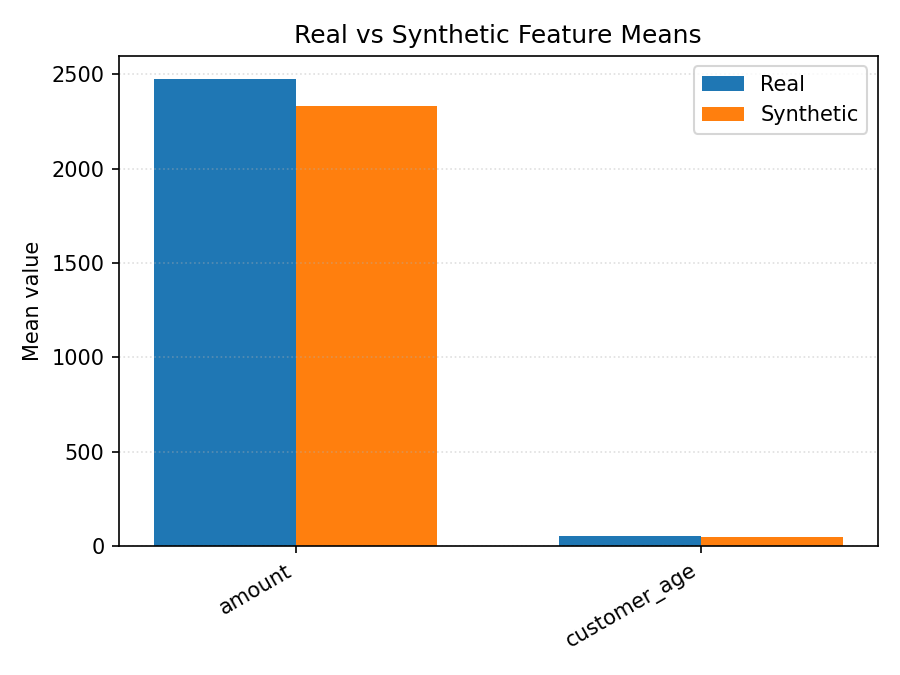

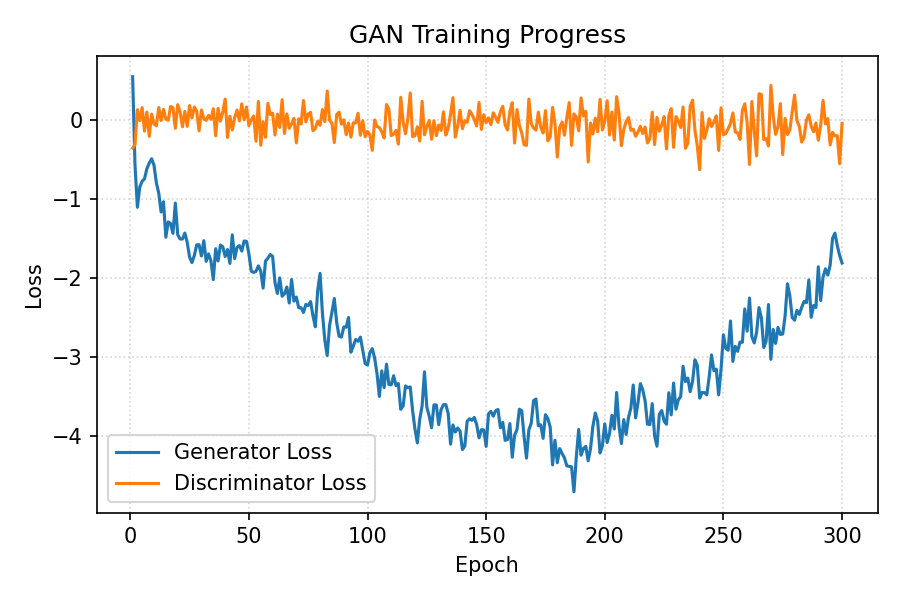

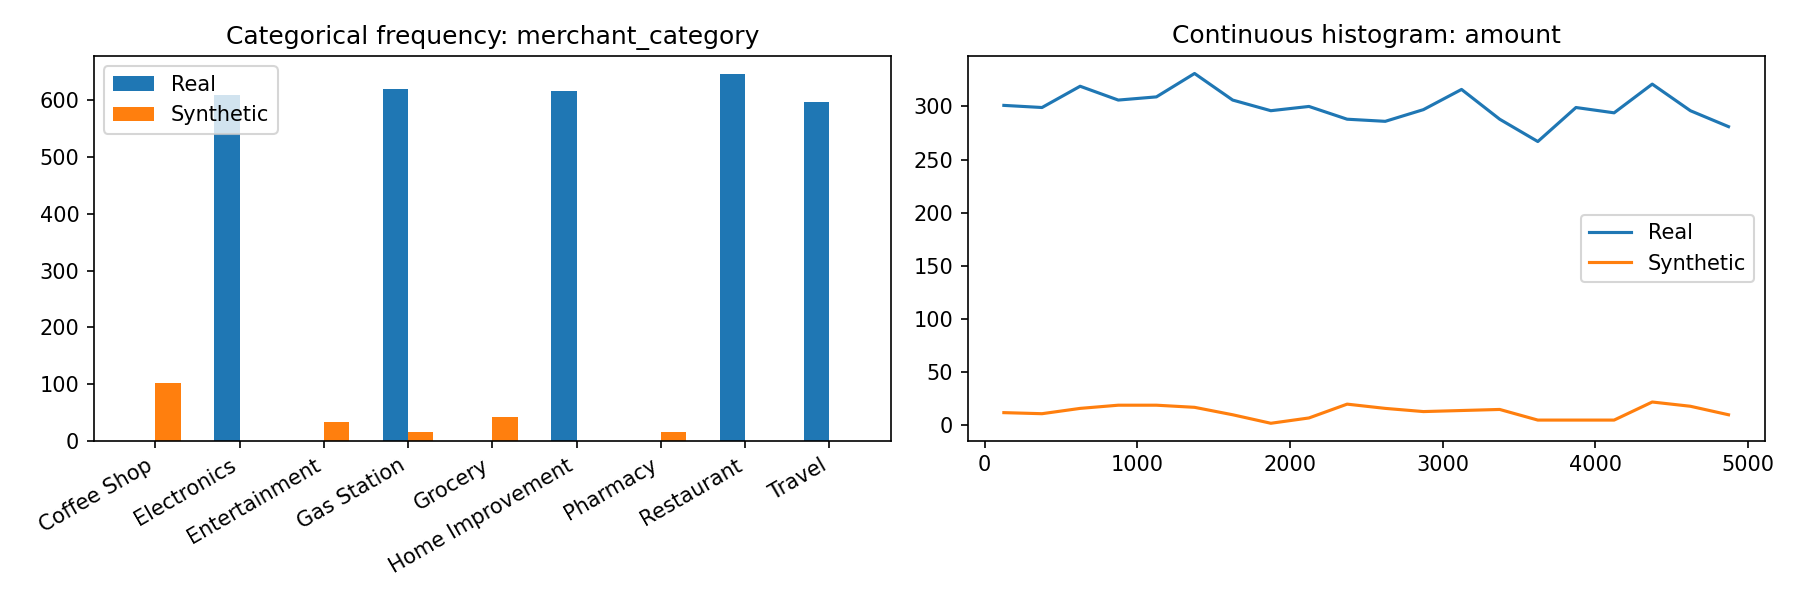

In [6]:
display(JSON(result["quality_report"]))
display(result["synthetic_preview"])

print("Synthetic CSV stored at:", result["synthetic_path"])
print("Metrics JSON stored at:", result["metrics_path"])
print("Testing report stored at:", result["testing_report_path"])

display(Image(filename=result["visualization_path"]))
display(Image(filename=result["training_history_path"]))
display(Image(filename=result["testing_visualization_path"]))

In [7]:
result["split_summary"]


{'train_fraction': 0.6,
 'train_size': 6000,
 'holdout_size': 4000,
 'split_seed': 123}

In [8]:
history = result["training_history"]
history[:5]


TypeError: unhashable type: 'slice'

In [ ]:
with open(result["synthetic_path"], "r", encoding="utf8") as handle:
    synthetic_records = list(csv.DictReader(handle))

len(synthetic_records)


In [ ]:
train_eval = compare_statistics(train_records, synthetic_records, numeric_features=schema.continuous_columns)
validation_eval = compare_statistics(validation_records, synthetic_records, numeric_features=schema.continuous_columns)
test_eval = compare_statistics(test_records, synthetic_records, numeric_features=schema.continuous_columns)

display(JSON({"train": train_eval.to_dict(), "validation": validation_eval.to_dict(), "test": test_eval.to_dict()}))


In [ ]:
manual_testing = {
    "train": generate_testing_report(train_records, synthetic_records, schema=schema),
    "validation": generate_testing_report(validation_records, synthetic_records, schema=schema),
    "test": generate_testing_report(test_records, synthetic_records, schema=schema),
}

JSON(manual_testing)


In [ ]:
testing_report = json.loads(Path(result["testing_report_path"]).read_text())
testing_report
